<a href="https://colab.research.google.com/github/kiryu2253-del/q-learning-maze/blob/main/q_learning_maze.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/kiryu2253-del/q-learning-maze/blob/main/q_learning_maze.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q-learning Maze

PythonでQ学習を使い，エージェントが迷路のゴールまでの経路を学習する．

- `0`：通れる道
- `1`：壁
- `S`：スタート
- `G`：ゴール


## 1. ライブラリを読み込む


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import random


## 2. 迷路を作る


In [10]:
maze = np.array([
    [0, 0, 1, 0, 0],
    [1, 0, 1, 0, 1],
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0]
])

start = (0, 0)
goal = (4, 4)

# 0:上，1:右，2:下，3:左
actions = {
    0: (-1, 0),
    1: (0, 1),
    2: (1, 0),
    3: (0, -1)
}

action_names = ["上", "右", "下", "左"]


## 3. 迷路を表示する


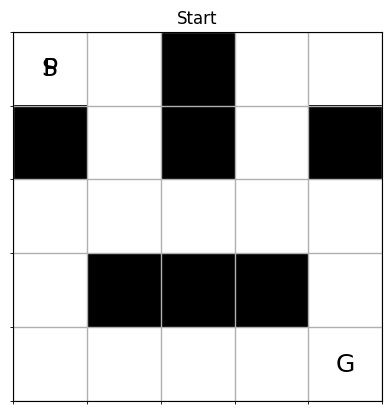

In [11]:
def show_maze(agent_position=None, path=None, title="Maze"):
    fig, ax = plt.subplots()
    ax.imshow(maze, cmap="binary")

    ax.text(start[1], start[0], "S", ha="center", va="center", fontsize=18)
    ax.text(goal[1], goal[0], "G", ha="center", va="center", fontsize=18)

    if agent_position is not None:
        ax.text(agent_position[1], agent_position[0], "P", ha="center", va="center", fontsize=18)

    if path is not None:
        x = [p[1] for p in path]
        y = [p[0] for p in path]
        ax.plot(x, y, marker="o")

    ax.set_xticks(np.arange(-0.5, 5, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 5, 1), minor=True)
    ax.grid(which="minor", linewidth=1)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    plt.title(title)
    plt.show()

show_maze(start, title="Start")


## 4. 状態と行動を定義する

5×5の各マスを，Qテーブルでは0〜24の状態番号で扱う．


In [12]:
def position_to_state(position):
    row, col = position
    return row * 5 + col

def move(position, action):
    row, col = position
    dr, dc = actions[action]

    new_row = row + dr
    new_col = col + dc

    # 迷路の外に出た場合
    if new_row < 0 or new_row >= 5 or new_col < 0 or new_col >= 5:
        return position, -5, False

    # 壁にぶつかった場合
    if maze[new_row][new_col] == 1:
        return position, -5, False

    new_position = (new_row, new_col)

    # ゴールした場合
    if new_position == goal:
        return new_position, 100, True

    # 普通に移動した場合
    return new_position, -1, False


## 5. 学習前のランダム移動

学習前はゴールへの道を知らないため，上下左右からランダムに行動する．


step 1 action 上 position (0, 0) reward -5
step 2 action 上 position (0, 0) reward -5
step 3 action 下 position (0, 0) reward -5
step 4 action 右 position (0, 1) reward -1
step 5 action 右 position (0, 1) reward -5
step 6 action 右 position (0, 1) reward -5
step 7 action 上 position (0, 1) reward -5
step 8 action 上 position (0, 1) reward -5
step 9 action 左 position (0, 0) reward -1
step 10 action 上 position (0, 0) reward -5


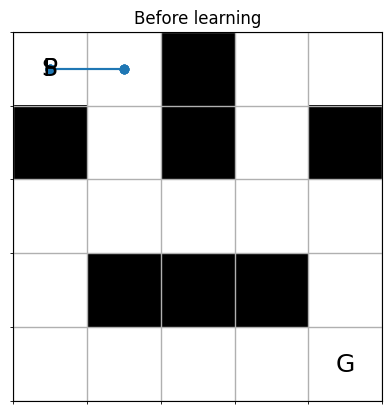

In [13]:
random.seed(42)

agent = start
random_path = [agent]

for step in range(10):
    action = random.randint(0, 3)
    agent, reward, done = move(agent, action)
    random_path.append(agent)
    print("step", step + 1, "action", action_names[action], "position", agent, "reward", reward)

show_maze(agent, random_path, title="Before learning")


## 6. Qテーブルと学習条件を設定する

Qテーブルは「状態25個 × 行動4個」．学習前はすべて0から始める．


In [14]:
num_states = 25
num_actions = 4

Q = np.zeros((num_states, num_actions))

alpha = 0.5       # 学習率
gamma = 0.9       # 割引率
epsilon = 1.0     # 最初はランダム行動を多くする
epsilon_min = 0.05
epsilon_decay = 0.995
episodes = 1000

print("Qテーブルの形:", Q.shape)


Qテーブルの形: (25, 4)


## 7. Q学習を行う

Q値は次の式で更新する．

$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[r + \gamma \max_{a'}Q(s',a') - Q(s,a)\right]$$


In [15]:
steps_history = []
reward_history = []

random.seed(42)
np.random.seed(42)

for episode in range(episodes):
    position = start
    total_reward = 0

    for step in range(100):
        state = position_to_state(position)

        # ε-greedy法
        if random.random() < epsilon:
            action = random.randint(0, 3)
        else:
            action = np.argmax(Q[state])

        new_position, reward, done = move(position, action)
        new_state = position_to_state(new_position)

        if done:
            target = reward
        else:
            target = reward + gamma * np.max(Q[new_state])

        Q[state, action] = Q[state, action] + alpha * (target - Q[state, action])

        position = new_position
        total_reward += reward

        if done:
            break

    steps_history.append(step + 1)
    reward_history.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

print("学習終了")


学習終了


## 8. 学習後のAIに迷路を解かせる


AIが見つけた経路:
(0, 0)
(0, 1)
(1, 1)
(2, 1)
(2, 2)
(2, 3)
(2, 4)
(3, 4)
(4, 4)
ゴールまでの移動回数: 8


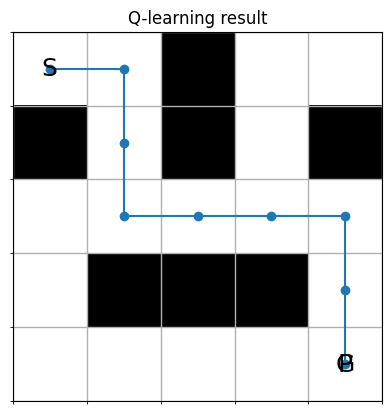

In [16]:
position = start
path = [position]

for i in range(30):
    if position == goal:
        break

    state = position_to_state(position)
    action = np.argmax(Q[state])

    new_position, reward, done = move(position, action)
    path.append(new_position)
    position = new_position

    if done:
        break

print("AIが見つけた経路:")
for p in path:
    print(p)

print("ゴールまでの移動回数:", len(path) - 1)

show_maze(position, path, title="Q-learning result")


## 9. 学習の変化をグラフで確認する


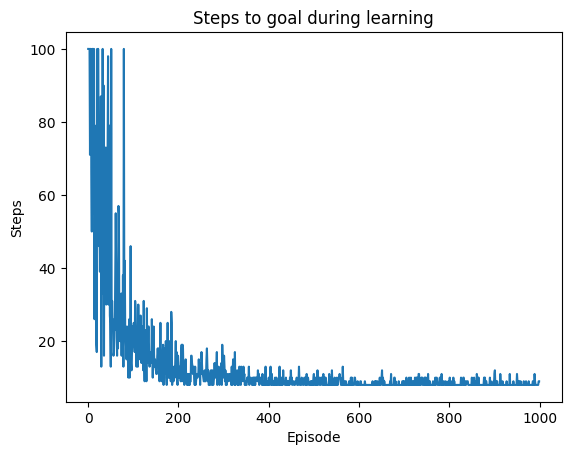

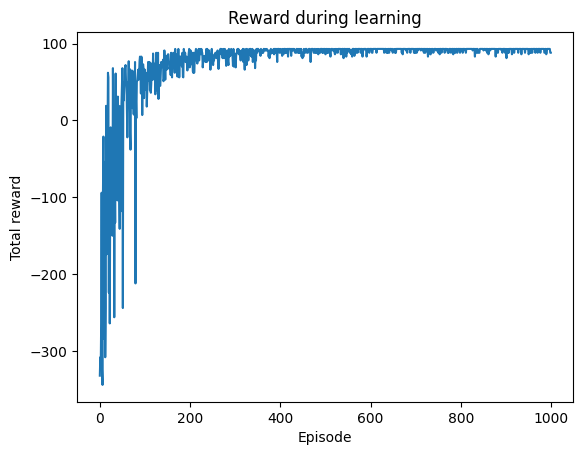

In [17]:
plt.figure()
plt.plot(steps_history)
plt.xlabel("Episode")
plt.ylabel("Steps")
plt.title("Steps to goal during learning")
plt.show()

plt.figure()
plt.plot(reward_history)
plt.xlabel("Episode")
plt.ylabel("Total reward")
plt.title("Reward during learning")
plt.show()
